# Screening results

This notebook summarizes the corpus-screening stage used to identify records that provide evidence of biodiversity change. It begins at the results boundary: full-source loading, key validation, eligibility accounting, direction accounting, and exclusion intersections are performed once in `../data-processing/03_screening_analysis_prep.ipynb`.

## Screening scope and assumptions

- The source corpus contains records returned by the study search-string query.
- Before screening, duplicate records were removed and records with null or empty abstracts were excluded. The final screening corpus contains **2,414,191 records**.
- The corpus was processed in 242 partitions, with run associations recorded in `checklists/mappings/run_names.json`.
- The original datasets, normalized requests, LLM payloads, and model outputs retain the end-to-end audit trail.
- This results notebook loads only a small processing manifest and the 15-row exclusion-overlap table; it never scans the 5.3 GB consolidated screening CSV.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers import results_config
from data_helpers.prep import evidence_corpus_prep


In [2]:
RESULTS_CONFIG = results_config.load_results_config()
PREP_CONFIG = RESULTS_CONFIG["screening_analysis_prep"]
CONFIG = RESULTS_CONFIG["screening_results"]
STORE = evidence_corpus_prep.ScreeningPreparedStore(PROJECT_ROOT / PREP_CONFIG["output_directory"])
STAGE_NAMES = evidence_corpus_prep.STAGE_NAMES
BIODIVERSITY_GREEN = "#2E7D32"
CONTEXT_GREEN = "#B8CDB2"
CHARCOAL = "#2B2B2B"
LIGHT_GRAY = "#050404"


## Summary

The processing manifest reconciles the complete screening grain, eligibility labels, operational eligibility flag, unclear-step rule, and direction counts.

In [3]:
manifest, overlap_table = STORE.load_analysis()
summary = manifest["summary"]
raw_columns = summary["raw_columns"]
print(f"Grain check passed: all {summary['screened_records']:,} records have a unique, non-null UT.")
print(f"The raw dataset contains {summary['raw_column_count']} columns: {' , '.join(raw_columns)}")
print(f"Screening classified {summary['eligibility_label_eligible']:,} records as eligible and {summary['eligibility_label_not_eligible']:,} records as not eligible.")
print(f"Of all eligible records, {summary['eligible_with_unclear_step']:,} were assumed eligible despite at least one unclear screening step.")
print(f"Of all eligible records, {summary['eligible_negative']:,} report a negative impact on biodiversity.")
print(f"Records with positive, mixed, unclear, or missing direction of change: not analyzed in loss-focused results (n = {summary['eligible_not_negative']:,}).")


Grain check passed: all 2,414,191 records have a unique, non-null UT.
The raw dataset contains 24 columns: UT , title , authors , abstract , source , publication_year , wos_categories , doi , custom_id , model , created_at , raw_output , pred , s1_r , s2_r , s3_r , s4_r , s1_bio , s2_dir , s3_drivers , s4_link , _source_run , is_eligible , eligibility
Screening classified 605,199 records as eligible and 1,808,992 records as not eligible.
Of all eligible records, 121,707 were assumed eligible despite at least one unclear screening step.
Of all eligible records, 253,081 report a negative impact on biodiversity.
Records with positive, mixed, unclear, or missing direction of change: not analyzed in loss-focused results (n = 352,118).


## Direction of change among eligible records

Only records classified as `negative` enter loss-focused results; positive, mixed, unclear, or missing direction states remain in the shared eligible corpus for analyses that require them.

In [4]:
eligible_direction_breakdown = pd.DataFrame(manifest["eligible_direction_audit"])
display(eligible_direction_breakdown.style.format({"records": "{:,}", "percent_of_eligible": "{:.2f}%"}).hide(axis="index"))


direction_of_change,percent_of_eligible,records
negative,41.82%,"253,081"
mixed,23.34%,"141,267"
positive,18.62%,"112,684"
unclear,16.22%,"98,167"


## Reasons for exclusion

The table and diagram show every observed combination of screening steps with a result of `0`. No priority or ordering is assigned to the steps.

In [5]:
display(overlap_table[["intersection", "combination", "records", "percent"]].style.format({"records": "{:,}", "percent": "{:.2f}%"}).hide(axis="index"))


intersection,combination,records,percent
1,Q1: biodiversity change + Q2: direction of change + Q3: anthropogenic driver + Q4: driver-change linkage,"1,081,249",59.77%
2,Q1: biodiversity change + Q2: direction of change + Q4: driver-change linkage,"435,966",24.10%
3,Q3: anthropogenic driver + Q4: driver-change linkage,"217,696",12.03%
4,Q1: biodiversity change + Q2: direction of change,"35,857",1.98%
5,Q4: driver-change linkage,"13,742",0.76%
6,Q3: anthropogenic driver,"11,332",0.63%
7,Q1: biodiversity change,"6,645",0.37%
8,Q1: biodiversity change + Q3: anthropogenic driver + Q4: driver-change linkage,"2,913",0.16%
9,Q1: biodiversity change + Q4: driver-change linkage,"1,411",0.08%
10,Q2: direction of change,948,0.05%


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/00_screening/screening_criteria_overlap.pdf


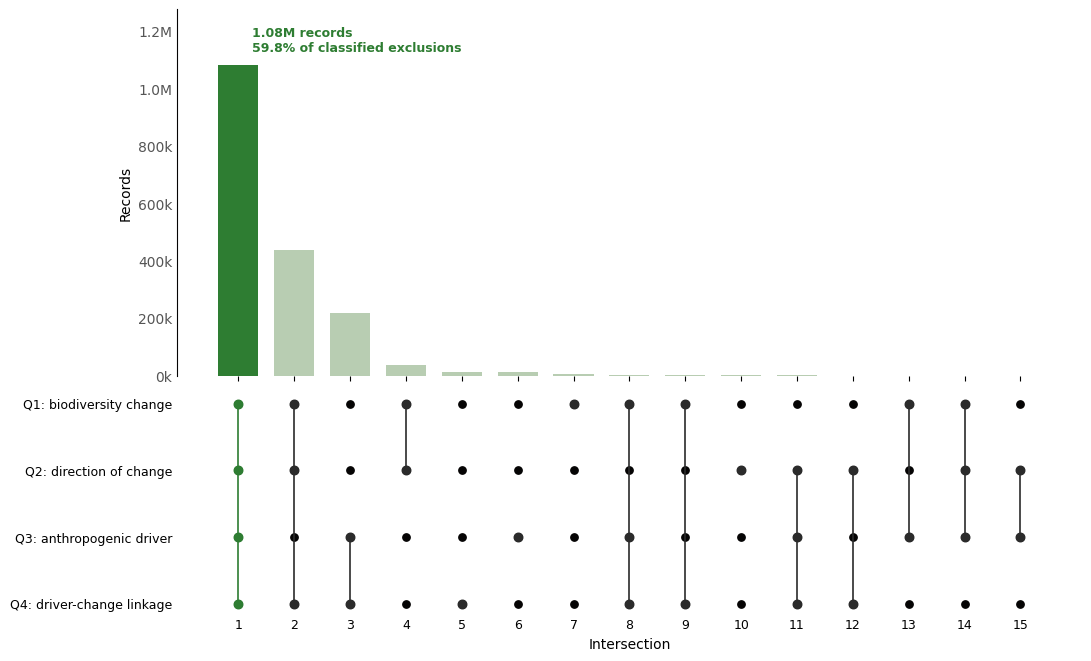

In [6]:
stage_labels = list(STAGE_NAMES.values())
x_positions = range(len(overlap_table))
fig, (count_ax, matrix_ax) = plt.subplots(2, 1, figsize=(max(10, len(overlap_table) * 0.72), 6.5), sharex=True, layout="constrained", gridspec_kw={"height_ratios": [3, 1.8], "hspace": 0.03})
bar_colors = [BIODIVERSITY_GREEN] + [CONTEXT_GREEN] * (len(overlap_table) - 1)
count_ax.bar(x_positions, overlap_table["records"], color=bar_colors, width=0.72)
count_ax.set_ylabel("Records")
count_ax.yaxis.set_major_formatter(lambda value, position: f"{value / 1_000_000:.1f}M" if value >= 1_000_000 else f"{value / 1_000:.0f}k")
count_ax.tick_params(axis="y", length=0, colors="#555555")
count_ax.spines[["top", "right", "bottom"]].set_visible(False)
count_ax.spines["left"].set_color(LIGHT_GRAY)
largest = overlap_table.iloc[0]
count_ax.annotate(f"{largest['records'] / 1_000_000:.2f}M records\n{largest['percent']:.1f}% of classified exclusions", xy=(0, largest["records"]), xytext=(10, 8), textcoords="offset points", color=BIODIVERSITY_GREEN, fontsize=9, fontweight="bold", ha="left", va="bottom")
count_ax.margins(y=0.18)
for x, row in overlap_table.iterrows():
    active_rows = [i for i, stage in enumerate(stage_labels) if row[stage]]
    active_color = BIODIVERSITY_GREEN if x == 0 else CHARCOAL
    matrix_ax.scatter([x] * len(stage_labels), range(len(stage_labels)), color=LIGHT_GRAY, s=28)
    matrix_ax.scatter([x] * len(active_rows), active_rows, color=active_color, s=38, zorder=3)
    if len(active_rows) > 1:
        matrix_ax.plot([x, x], [min(active_rows), max(active_rows)], color=active_color, linewidth=1.2)
matrix_ax.set_yticks(range(len(stage_labels)), stage_labels)
matrix_ax.set_xticks(list(x_positions), overlap_table["intersection"])
matrix_ax.set_xlabel("Intersection")
matrix_ax.invert_yaxis()
matrix_ax.tick_params(axis="both", length=0, labelsize=9)
matrix_ax.spines[:].set_visible(False)
output_dir = PROJECT_ROOT / CONFIG["output_directory"]
output_dir.mkdir(parents=True, exist_ok=True)
figure_path = output_dir / f"{CONFIG['figure_filename']}.pdf"
fig.canvas.draw()
fig.set_layout_engine("none")
fig.savefig(figure_path, bbox_inches="tight")
print(f"Saved: {figure_path}")
plt.show()
